In [1]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt

from nnfabrik.builder import get_data
from sensorium.utility.scores import get_correlations, get_poisson_loss
from modified_neuralpredictors.create_model import stacked_core_full_gauss_readout
from sklearn.manifold import TSNE

# For notebooks, use current working directory instead of __file__
current_dir = os.getcwd()  # Gets the current working directory
project_root = os.path.dirname(current_dir)  # Go up one level if needed

current_file = os.path.join(os.getcwd(), 'notebook.ipynb')
current_dir = os.getcwd()

sys.path.insert(0, project_root)

from models.autoencoder import Autoenc

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = 'cuda:0'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"

# as filenames, we'll select all 7 datasets
filenames = [
    os.path.join(basepath, file) for file in os.listdir(basepath) if ".zip" in file
]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "batch_size": 128,
    "scale": 0.25, 
}
dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

model_config = {
    'hidden_channels': 64, # original sensorium was 64ch
    'depth_separable': False,
    'use_avg_reg': False,
    'laplace_padding': None,
    'momentum': 0.75,
    'final_nonlinearity': True,
    'nonlinearity_type': 'AdaptiveELU',
    'pad_input': False,
    'stack': -1,
    'layers': 4,
    'input_kern': 11, #  original sensorium was 'input_kern': 9,
    'gamma_input': 6.3831, # this should not influence the performance based on previous experience
    
    'feature_reg_weight': 3, # this is the one I actually would like to tune!
    
    'hidden_kern': 7,
    'grid_mean_predictor': {
        'type': 'cortex',
        'input_dimensions': 2,
        'hidden_layers': 1,
        'hidden_features': 30,
        'final_tanh': True
    },
    
    'init_sigma': 0.1,
    'init_mu_range': 0.3,
    'gauss_type': 'full',
    'shifter': True,
    'batch_norm_scale': [True, True, True, False],
    'core_bias': [True, True, True, False],
    'regularizer_type': "adaptive_log_norm",
    'gamma_sigma' : 0.25,
}

model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)
model.load_state_dict(torch.load('runs/base/exp3/model_weights.pth'))
model.to(device);

/srv/user/nathanpaul.soeding/private_neuropredictors/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(
/srv/user/nathanpaul.soeding/private_neuropredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


In [2]:
latent_dims = [32, 16, 8, 4, 2]
poisson_autoenc_paths = [
    'runs/autoenc/exp18/autoencoder_weights.pth', 
    'runs/autoenc/exp19/autoencoder_weights.pth', 
    'runs/autoenc/exp20/autoencoder_weights.pth', 
    'runs/autoenc/exp21/autoencoder_weights.pth', 
    'runs/autoenc/exp22/autoencoder_weights.pth', 
]
poisson_autoencoder_config = {
    'input_dim': model_config['hidden_channels'], 
    'hidden_dims': [256],
    'batch_norm': False,
    'nonlinearity': 'ReLU', 
}

mse_autoenc_paths = [
    'runs/recon_autoenc/exp3/autoencoder_weights.pth',
    'runs/recon_autoenc/exp4/autoencoder_weights.pth',
    'runs/recon_autoenc/exp5/autoencoder_weights.pth',
    'runs/recon_autoenc/exp6/autoencoder_weights.pth',
    'runs/recon_autoenc/exp7/autoencoder_weights.pth',
]
mse_autoencoder_config = {
    'input_dim': model_config['hidden_channels'],
    'hidden_dims': [256, 256, 256], 
    'batch_norm': False,
    'nonlinearity': 'ReLU',
}

In [4]:
def plot_correlations(fn, latent_dims, autoenc_paths, autoenc_config, label):
    correlations = []
    for latent_dim, autoenc_path in zip(latent_dims, autoenc_paths):
        autoenc = Autoenc(latent_dim=latent_dim, **autoenc_config)
        autoenc.load_state_dict(torch.load(autoenc_path))
        autoenc.to('cuda:0')

        for key in data_keys:
            model.readout[key].autoencoder = autoenc
        
        model.eval()
        validation_score = fn(
            model, dataloaders["validation"], device='cuda:0', as_dict=False, per_neuron=False, 
        )
        correlations.append(validation_score)

    print(correlations)
    plt.plot(latent_dims, correlations, label=label)

base: 0.37980473
[np.float32(0.36469486), np.float32(0.33564717), np.float32(0.28447637), np.float32(0.22354273), np.float32(0.18111594)]
[np.float32(0.3685649), np.float32(0.34315842), np.float32(0.30746084), np.float32(0.2591164), np.float32(0.20962755)]


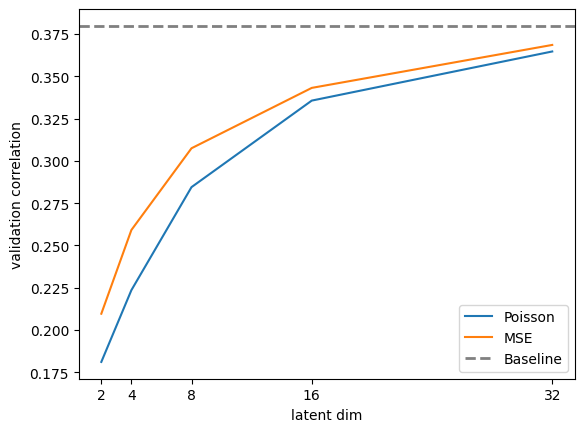

In [5]:
# Base model
model.eval()
base_score = get_correlations(
    model, dataloaders["validation"], device='cuda:0', as_dict=False, per_neuron=False,
)
print('base:', base_score)

plot_correlations(get_correlations, latent_dims, poisson_autoenc_paths, poisson_autoencoder_config, label='Poisson')
plot_correlations(get_correlations, latent_dims, mse_autoenc_paths, mse_autoencoder_config, label='MSE')

plt.ylabel('validation correlation')
plt.xlabel('latent dim')
plt.xticks(latent_dims)
plt.axhline(y=base_score, color='gray', linestyle='--', linewidth=2, label='Baseline')
plt.legend()
plt.savefig('plots/autoencoder_correlation_comparison.png')
plt.show()

[np.float32(15958013.0), np.float32(16347839.0), np.float32(16905604.0), np.float32(17612626.0), np.float32(18230218.0)]
[np.float32(16134489.0), np.float32(16524798.0), np.float32(16989132.0), np.float32(17632292.0), np.float32(18444848.0)]


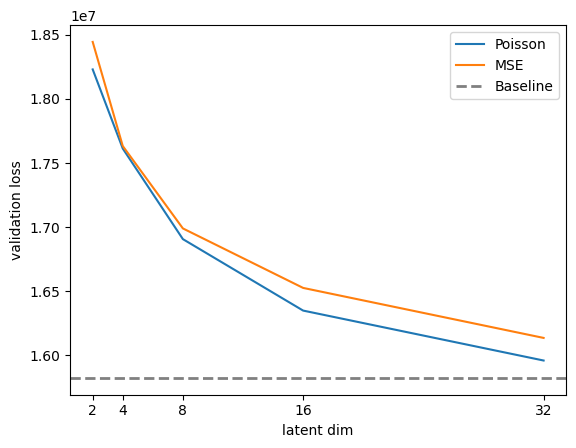

In [6]:
for key in data_keys:
    model.readout[key].autoencoder = None
    
model.eval()
base_loss = get_poisson_loss(
    model, dataloaders["validation"], device='cuda:0', as_dict=False, per_neuron=False,
)

plot_correlations(get_poisson_loss, latent_dims, poisson_autoenc_paths, poisson_autoencoder_config, label='Poisson')
plot_correlations(get_poisson_loss, latent_dims, mse_autoenc_paths, mse_autoencoder_config, label='MSE')

plt.ylabel('validation loss')
plt.xlabel('latent dim')
plt.xticks(latent_dims)
plt.axhline(y=base_loss, color='gray', linestyle='--', linewidth=2, label='Baseline')
plt.legend()
plt.savefig('plots/autoencoder_loss_comparison.png')
plt.show()

In [3]:
num_neurons_per_mouse = 2000

features = []
for key in data_keys:
    model.readout[key].autoencoder = None
    feat = model.readout[key].features.squeeze().T
    idcs = np.random.choice(feat.shape[0], num_neurons_per_mouse)
    features.append(feat[idcs])
features = torch.cat(features)

In [4]:
def plot_tsne(latent_dims, autoenc_paths, autoenc_config):
    fig, axes = plt.subplots(2, len(latent_dims), figsize=(25, 10))
    
    for idx, (latent_dim, autoenc_path) in enumerate(zip(latent_dims, autoenc_paths)):
        print(latent_dim)
        ax = axes[0][idx]
        autoenc = Autoenc(latent_dim=latent_dim, **autoenc_config)
        autoenc.load_state_dict(torch.load(autoenc_path))
        autoenc.to('cuda:0')
        autoenc.eval()

        enc_features = autoenc.encoder(features).detach().cpu().numpy()

        n = enc_features.shape[0]
        perplexity = n / 100
        lr = n / 12
        early_exaggeration = 12

        tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=lr, early_exaggeration=early_exaggeration, random_state=42)
        features_tsne = tsne.fit_transform(enc_features) if latent_dim > 2 else enc_features  # Run on unnormalized data

        ax.axis('off')
        ax.set_title(f'latent dim {latent_dim}')
        ax.scatter(features_tsne[:, 0], features_tsne[:, 1], s=1)

        ax = axes[1][idx]
        rec_features = autoenc(features).detach().cpu().numpy()
        rec_tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=lr, early_exaggeration=early_exaggeration, random_state=42)
        rec_features_tsne = rec_tsne.fit_transform(rec_features)  # Run on unnormalized data

        ax.axis('off')
        ax.set_title(f'reconstruction')
        ax.scatter(rec_features_tsne[:, 0], rec_features_tsne[:, 1], s=1)


32
16
8
4
2


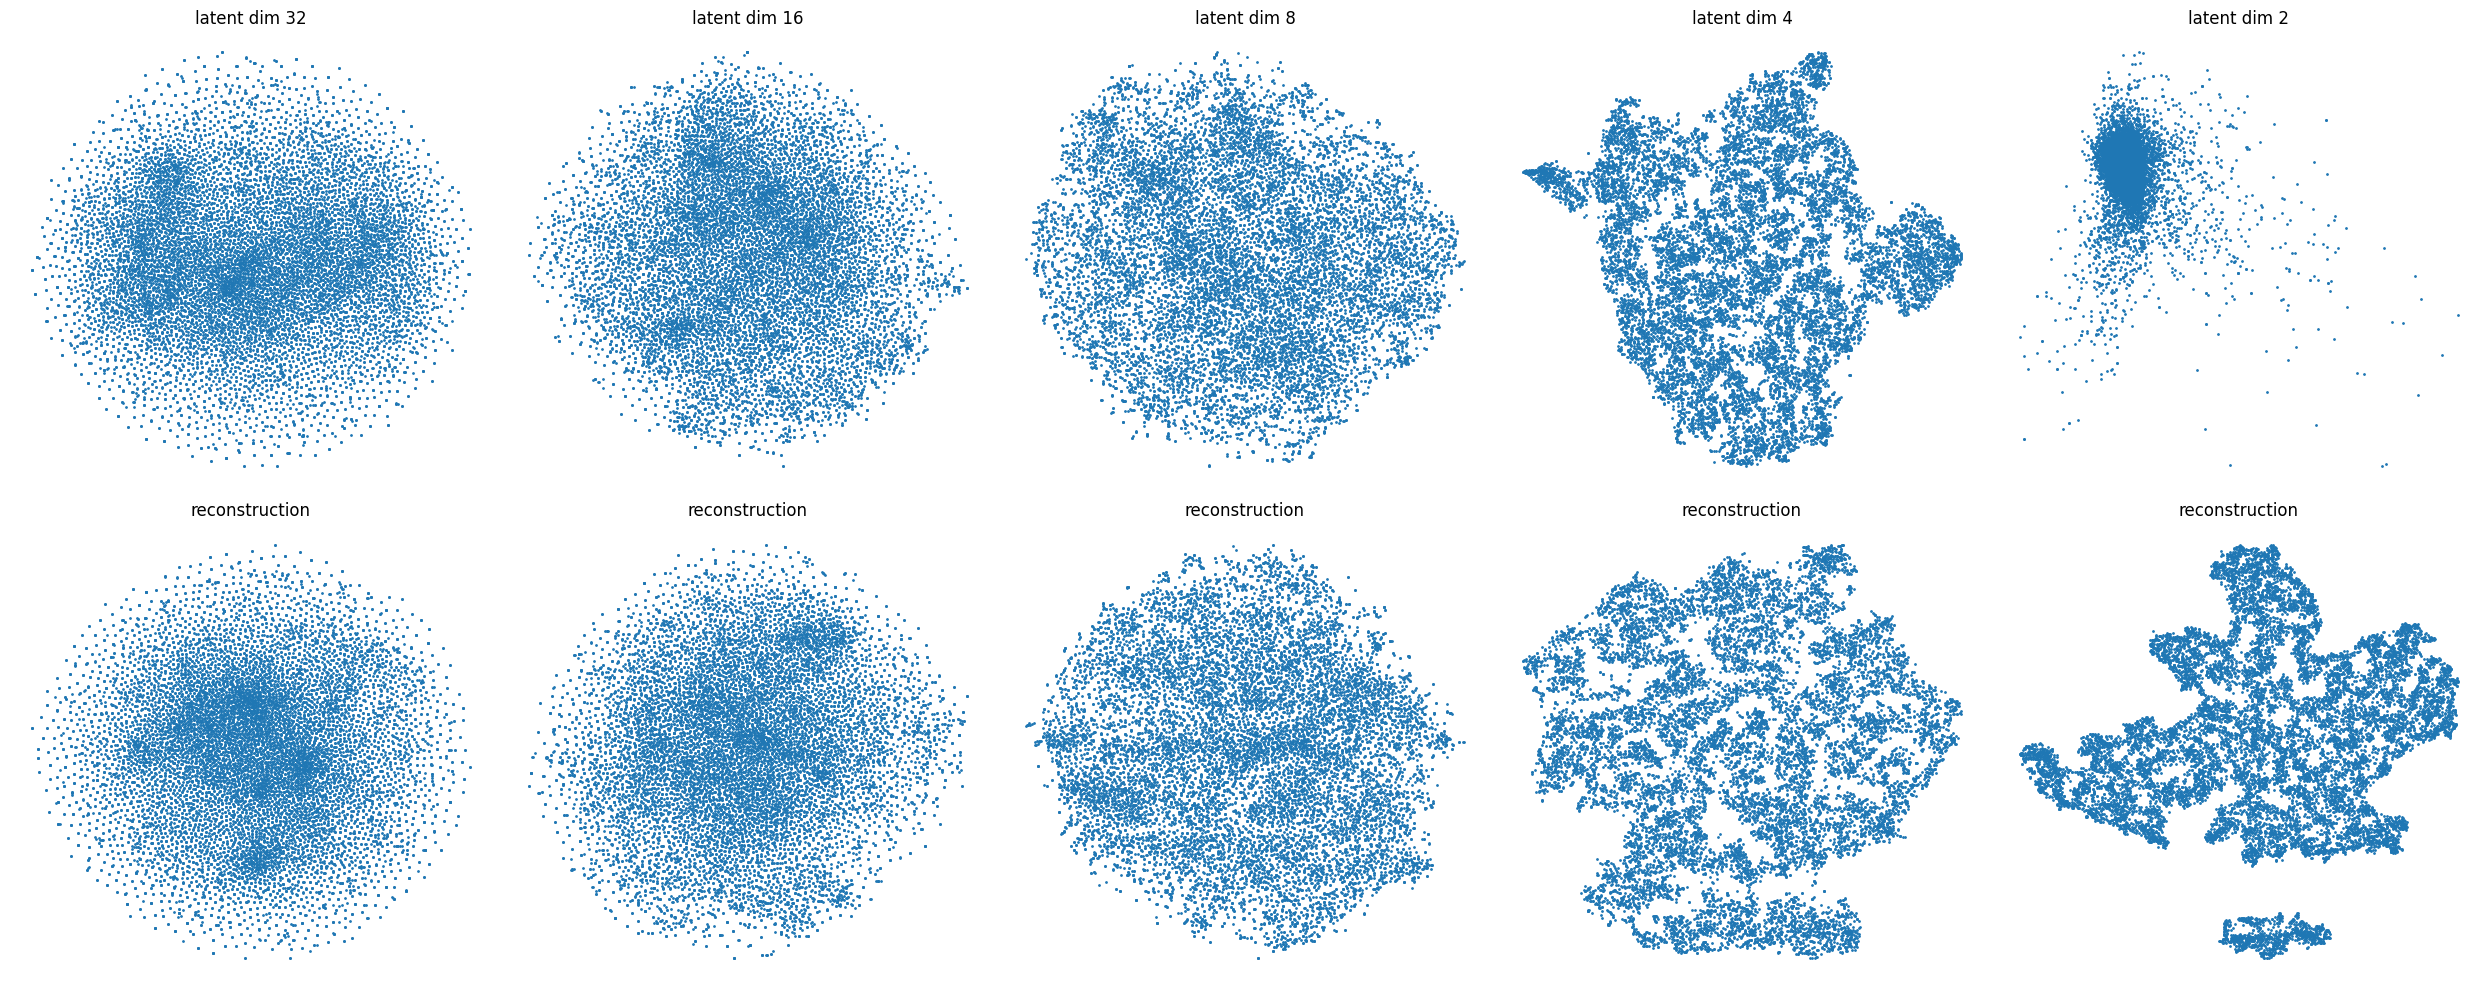

In [5]:
plot_tsne(latent_dims, poisson_autoenc_paths, poisson_autoencoder_config)
plt.tight_layout()
plt.savefig('plots/tsne_poisson.png')
plt.show()

32


16
8
4
2


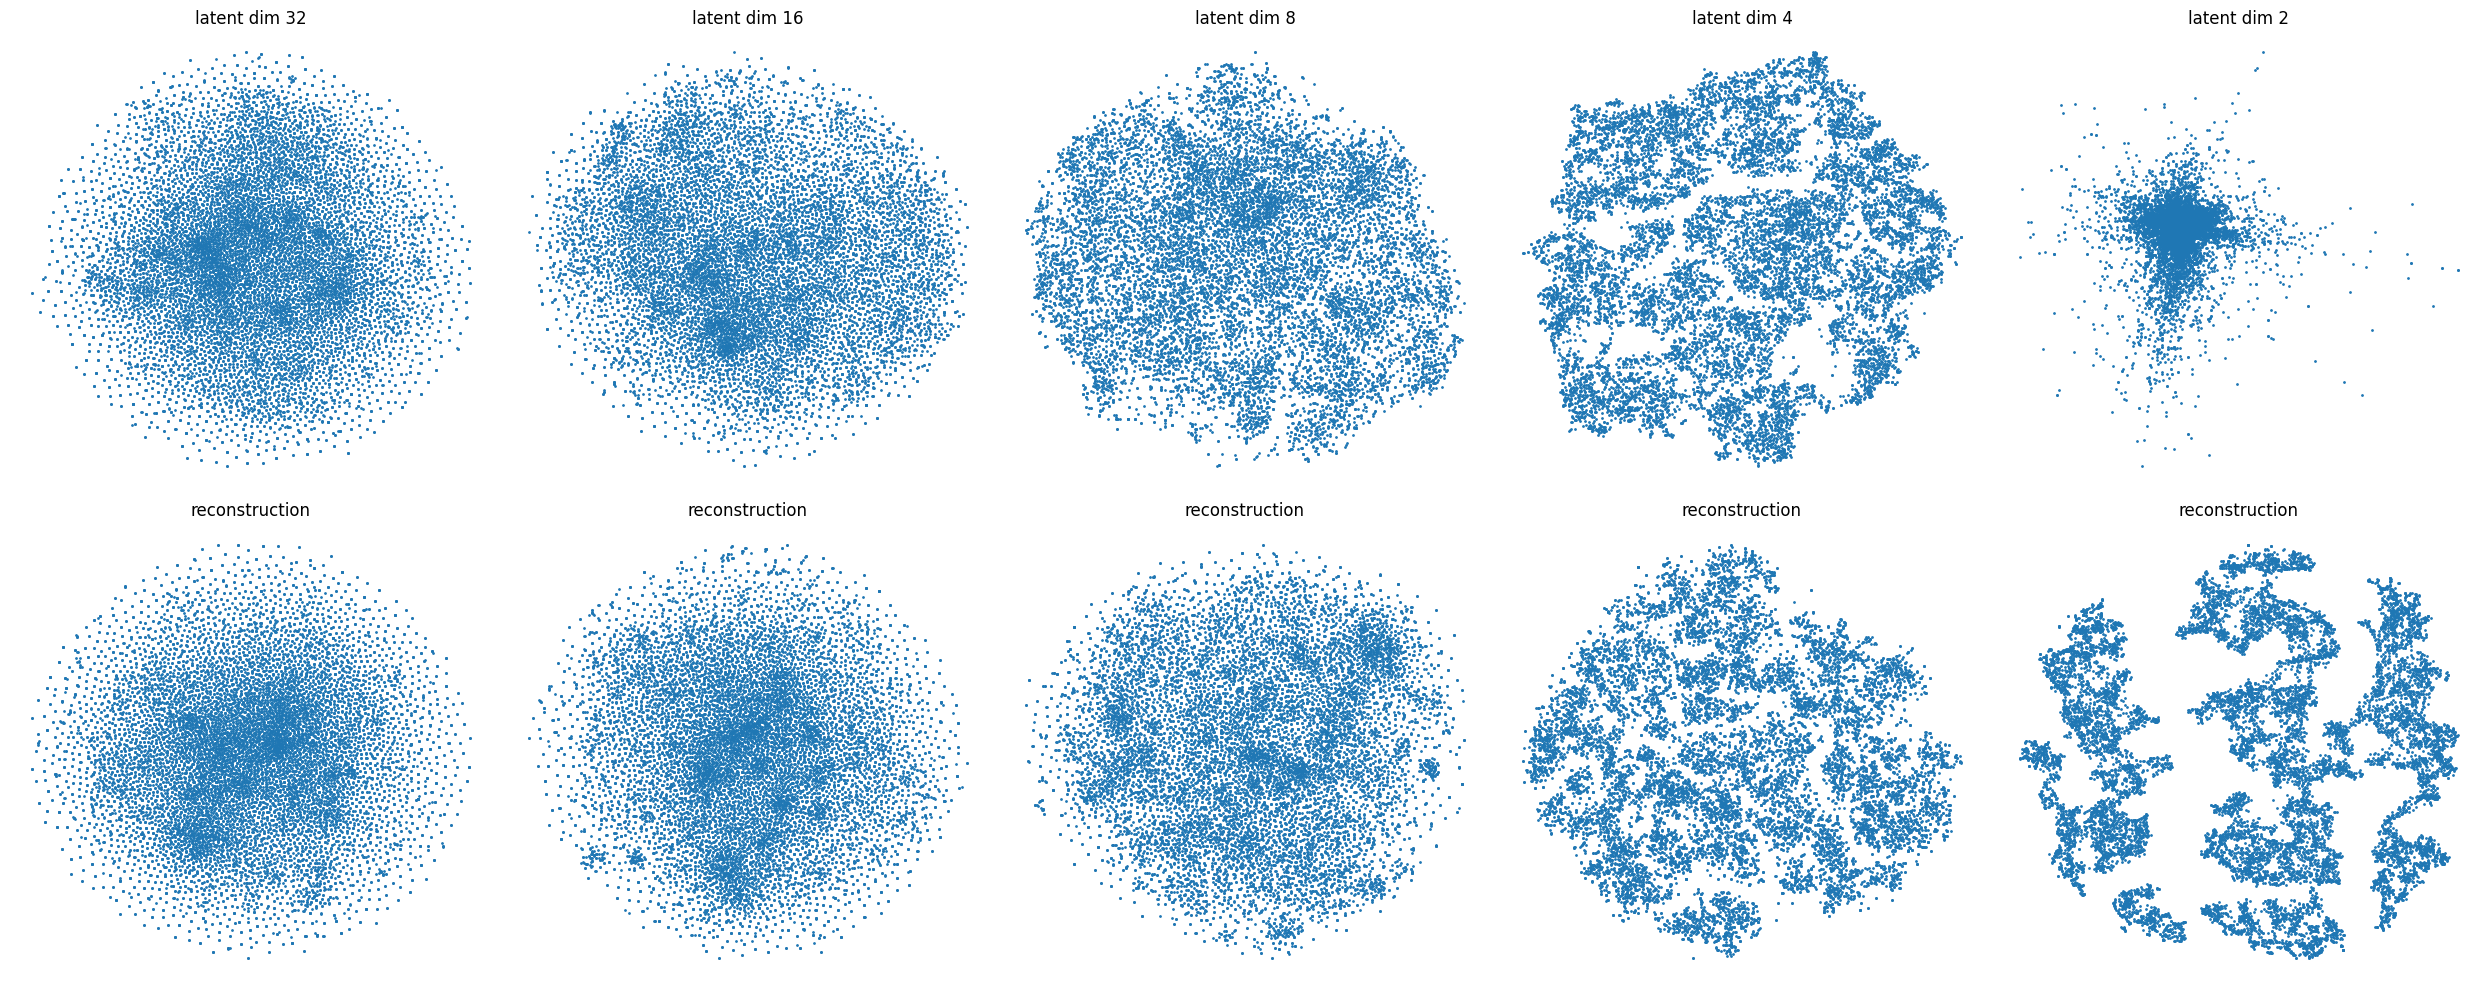

In [6]:
plot_tsne(latent_dims, mse_autoenc_paths, mse_autoencoder_config)
plt.tight_layout()
plt.savefig('plots/tsne_mse.png')
plt.show()